# Homework 4: Unsupervised Learning

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Exercise 1: Compute the SVD of a Matrix & Verify the Reconstruction

1. Construct any non-square matrix $A \in \mathbb{R}^{m \times n}$ (e.g. $m=10$, $n=6$) with random or structured entries.
2. Compute its SVD:
   
   $$
   A = U\Sigma V^T.
   $$


In [58]:
m = 10
n = 6
A = np.random.rand(m, n)
U, s, VT = np.linalg.svd(A, full_matrices=True)
print(U.shape, s.shape, VT.shape)


(10, 10) (6,) (6, 6)


In [59]:
S = np.zeros((m, n))
S[:n, :n] = np.diag(s)
S.shape

(10, 6)

3. Verify numerically that:
   
   $$
   A \approx U\Sigma V^T,
   \qquad
   \|A - U\Sigma V^T\|_F \approx 0.
   $$


In [60]:
np.linalg.norm(A - U @ S @ VT) 

np.float64(2.4538679914321598e-15)

4. Print and plot the singular values $\sigma_1,\dots,\sigma_{\min(m,n)}$.

In [61]:
print('Singular values of A:', s)

Singular values of A: [4.19728447 1.07948952 1.02786234 0.8190739  0.63266689 0.44331718]


5. Comment on why singular values appear in descending order, why small singular values correspond to “less important” directions, and why floating-point arithmetic makes exact zeros rare.


## Exercise 2: Best Rank-$k$ Approximation


1. Implement a function:
   
   $$
   A_k = \sum_{i=1}^k \sigma_i u_i v_i^T.
   $$

In [62]:
def compress_matrix(U, S, VT, k):
    """Compress matrix using top k singular values and vectors."""
    U_k = U[:, :k]
    S_k = S[:k, :k]
    VT_k = VT[:k, :]
    A_k = U_k @ S_k @ VT_k
    return A_k

2. For several values of $k$, compute:
   
   $$
   E(k) = \|A - A_k\|_F.
   $$


In [63]:
errors = []
for k in range(len(s)):
    A_k = compress_matrix(U, S, VT, k+1)
    error = np.linalg.norm(A - A_k)
    errors.append(error)
    print(f'Error with k={k+1}: {error}')

Error with k=1: 1.8680144990677496
Error with k=2: 1.5245263358071717
Error with k=3: 1.1259127687686903
Error with k=4: 0.7725267089027226
Error with k=5: 0.44331717603333315
Error with k=6: 2.4538679914321598e-15


3. Plot the approximation error $E(k)$ vs $k$.

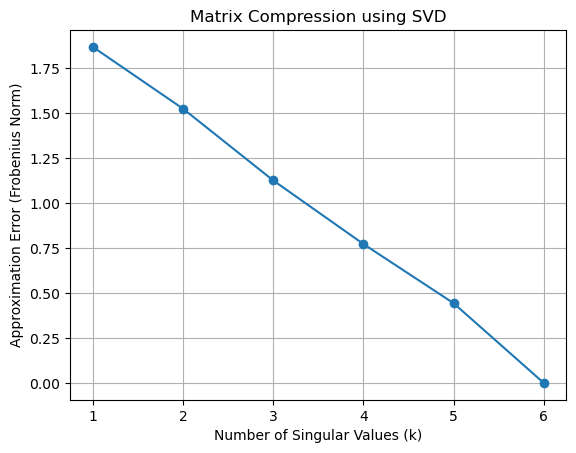

In [64]:
plt.plot(range(1, len(s)+1), errors, marker='o')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Approximation Error (Frobenius Norm)')
plt.title('Matrix Compression using SVD')
plt.grid()
plt.show()


4. Explain why SVD gives the *optimal* rank-$k$ approximation.

## Exercise 3: Image Compression with SVD

Using the `cameraman` image (as in the notes):

1. Load the image as a matrix $X \in \mathbb{R}^{512\times512}$.

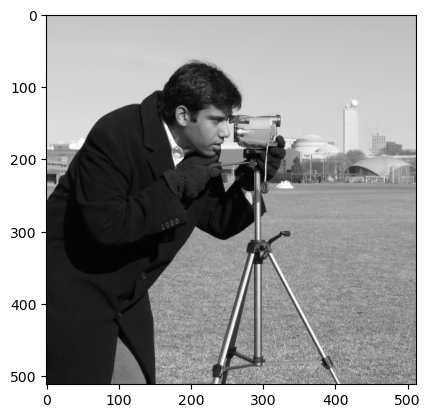

In [65]:
import skimage 

x = skimage.data.camera()
plt.imshow(x, cmap="gray")
plt.show()

2. Compute its SVD:
   
   $$
   X = U\Sigma V^T.
   $$

In [66]:
U, s, VT = np.linalg.svd(x, full_matrices=False)
print("SVD: ",U.shape, " @ ", s.shape," @ ", VT.shape)

SVD:  (512, 512)  @  (512,)  @  (512, 512)


3. For $k \in \{5, 20, 50, 100, 200\}$:
   - Compute the rank-$k$ approximation $X_k$,
   - Plot each reconstructed image,
   - Compute the compression factor:
     
     $$
     c_k
     = 1 - \frac{k(m+n+1)}{mn}.
     $$

   - Plot reconstruction error vs $k$,
   - Plot compression factor vs $k$.

In [67]:
k_values = [5, 20, 50, 100, 200]

compression_results = pd.DataFrame(columns=['k', 'Compressed_Image', 'Error', 'compression factor'])

for k in k_values:
    x_k = compress_matrix(U, np.diag(s), VT, k)
    error = np.linalg.norm(x - x_k)
    m = U.shape[0]
    n = VT.shape[1]
    compression_factor = 1 - (k*(m + 1 + n) / (m*n))
    compression_results.loc[len(compression_results)] = [k, x_k, error, compression_factor]

display(compression_results.drop(columns=['Compressed_Image']))

,k,Error,compression factor
0,5,13086.868265,0.980450
1,20,7699.909142,0.921799
2,50,4836.068908,0.804497
3,100,2992.144382,0.608994
4,200,1342.358197,0.217987


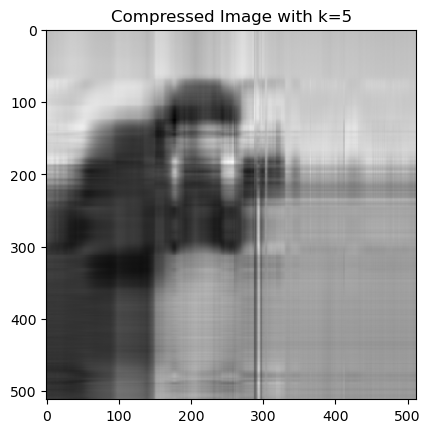

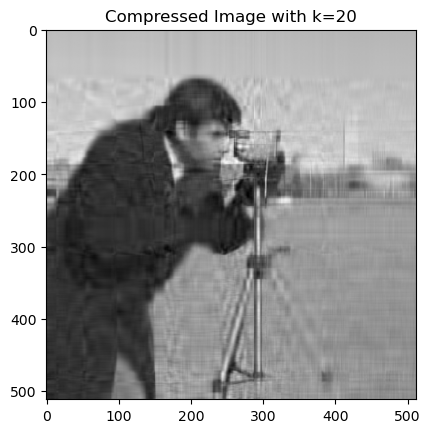

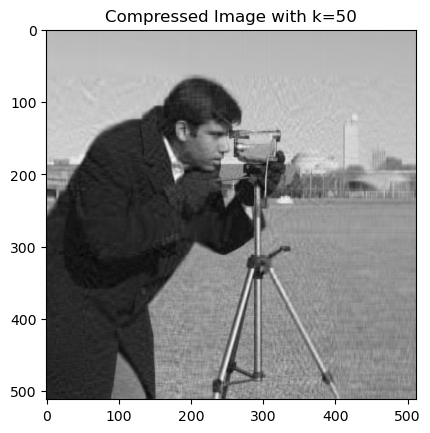

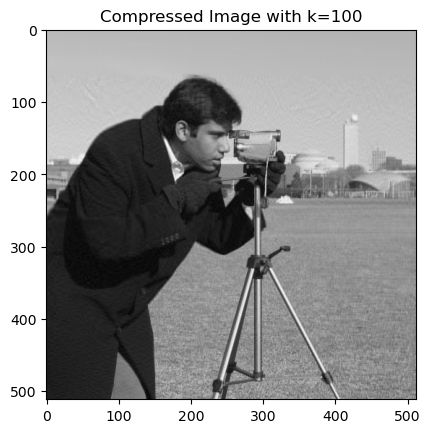

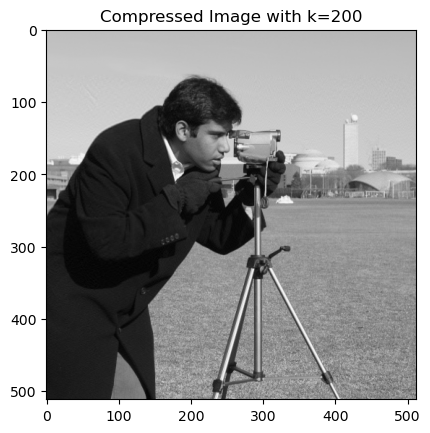

In [68]:
for index, row in compression_results.iterrows():
    plt.imshow(row['Compressed_Image'], cmap='gray')
    plt.title(f'Compressed Image with k={row["k"]}')
    plt.show()

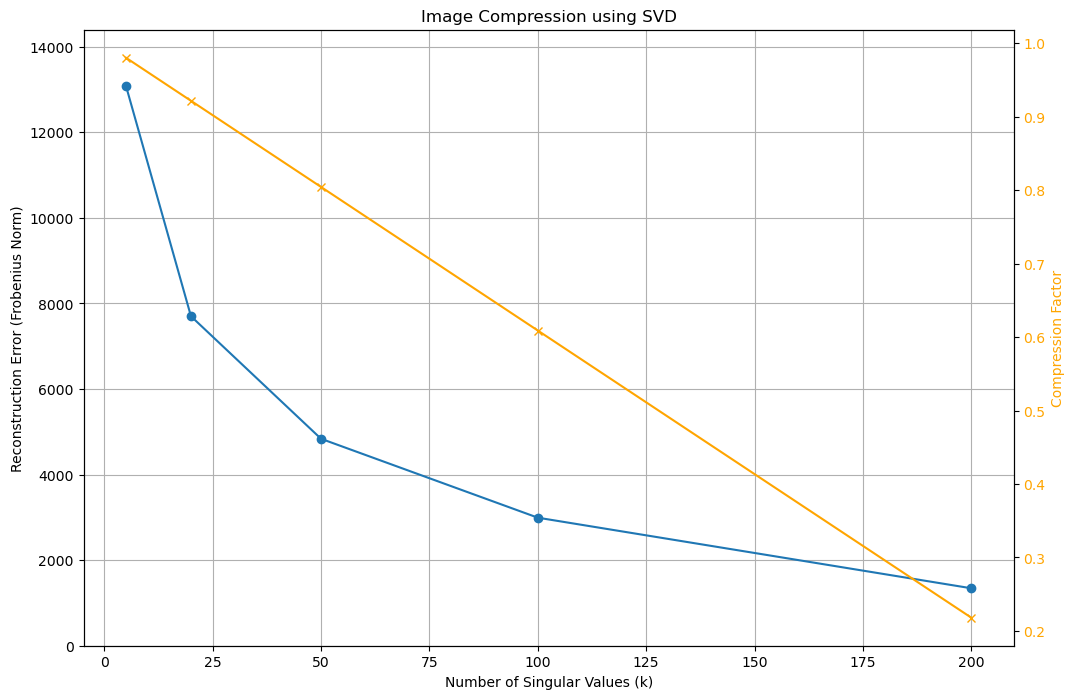

In [69]:
# plot reconstruction error vs k
_, ax = plt.subplots(figsize=(12, 8))
ax.plot(compression_results['k'], compression_results['Error'], marker='o')
ax.set_xlabel('Number of Singular Values (k)')
ax.set_ylabel('Reconstruction Error (Frobenius Norm)')
ax.set_ylim(0, max(compression_results['Error']) * 1.1)
ax.set_title('Image Compression using SVD')
ax.grid()

ax2 = ax.twinx()
ax2.plot(compression_results['k'], compression_results['compression factor'], color='orange', marker='x')
ax2.set_ylabel('Compression Factor', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.show()

4. Comment on:
   - How visual quality improves with $k$,
   - Why most of the “energy” is contained in the first singular values,
   - The trade-off between compression and fidelity,
   - The connection between SVD and optimal low-rank approximation.

## Exercise 5: PCA + Clustering on a Real Dataset

Use the MNIST Kaggle dataset: https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer.

To reduce computational burden, **filter only digits 3 and 4** exactly as in the teaching notes.

Do as follows:
1. Load the CSV file into memory (you may use NumPy or pandas).

In [71]:
import numpy as np
 

df = pd.read_csv('./MNIST.csv')
df.shape

(42000, 785)

In [72]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [73]:
X = df.drop(columns=['label']).values
y = df['label'].values

print(f"Shape of the data: {X.shape}, Labels: {y.shape}")

Shape of the data: (42000, 784), Labels: (42000,)


In [74]:
filter_3or4 = (y==3) | (y==4)

X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

print(f"Final shape of X: {X_filtered.shape}. Final shape of Y: {Y_filtered.shape}")
print(f"Number of class 3 samples: {np.sum(Y_filtered==3)}")
print(f"Number of class 4 samples: {np.sum(Y_filtered==4)}")

Final shape of X: (8423, 784). Final shape of Y: (8423,)
Number of class 3 samples: 4351
Number of class 4 samples: 4072


2. Split into training and test sets.

In [75]:
N = X_filtered.shape[0]
random_indices = np.random.permutation(N)

N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]

X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]

print(f"Train set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Train set: 6738 samples, Test set: 1685 samples


3. Center the training data:
   
   $$
   X_{c,\text{train}} = X_{\text{train}} - c(X_{\text{train}}).
   $$

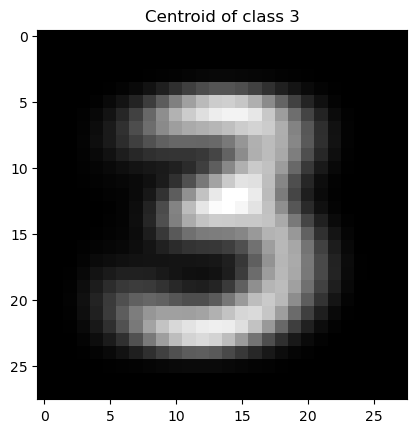

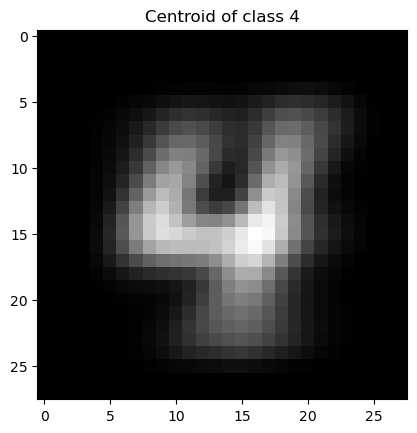

In [76]:
X_3 = X_filtered[Y_filtered==3]
X_4 = X_filtered[Y_filtered==4]

centroid_of_X_3 = np.mean(X_3, axis=0)
centroid_of_X_4 = np.mean(X_4, axis=0)

# Visualize centroids
img_3 = np.reshape(centroid_of_X_3, (28, 28))
plt.imshow(img_3, cmap='gray')
plt.title('Centroid of class 3')
plt.show()

img_4 = np.reshape(centroid_of_X_4, (28, 28))
plt.imshow(img_4, cmap='gray')
plt.title('Centroid of class 4')
plt.show()

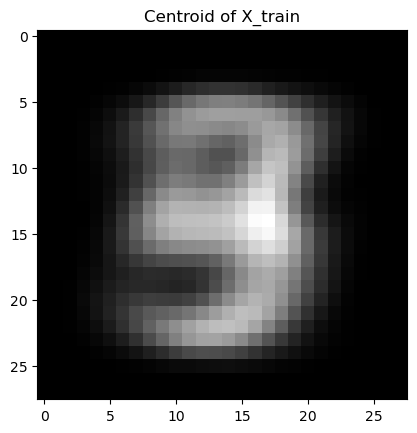

In [77]:
centroid_of_X_train = np.mean(X_train, axis=0)
centroid_of_X_test = np.mean(X_test, axis=0)

centroid_of_X_train_img = np.reshape(centroid_of_X_train, (28, 28))
plt.imshow(centroid_of_X_train_img, cmap='gray')
plt.title('Centroid of X_train')
plt.show()

4. Compute the reduced SVD of the centered training data.

In [78]:
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

5. Choose $k=2$ principal components.
6. Project:
   - $Z_{\text{train}} = X_{c,\text{train}} V_2$,
   - $Z_{\text{test}} = X_{c,\text{test}} V_2$.

In [79]:
k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T


7. Plot:
   - Scatterplot of $Z_{\text{train}}$ colored by labels (3 vs 4),
   - Scatterplot of $Z_{\text{test}}$ overlaid in the same plot.

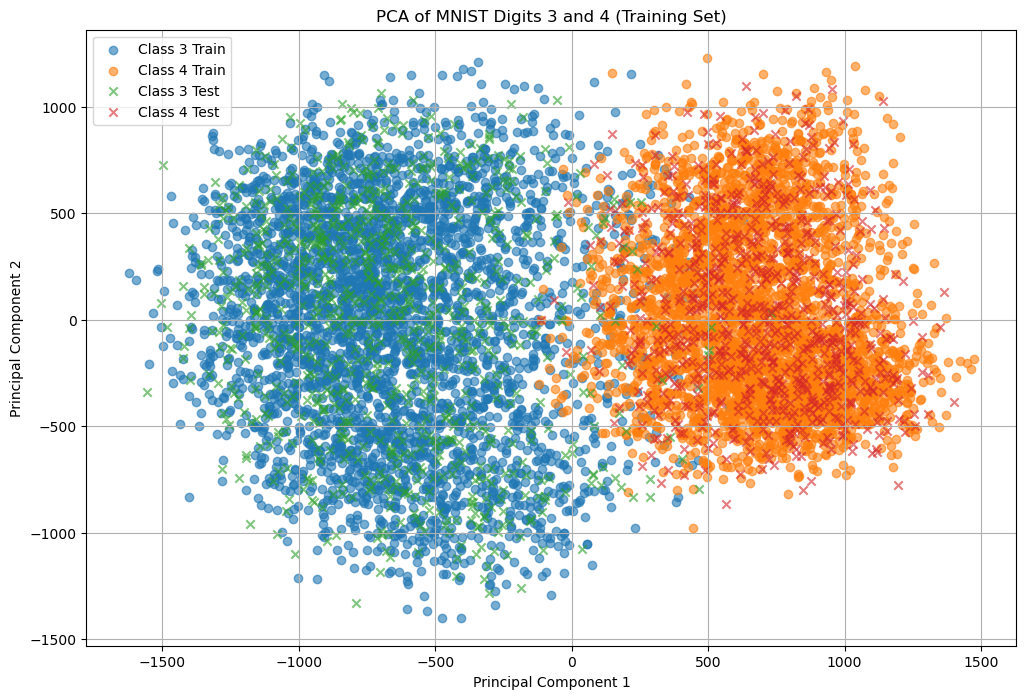

In [80]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], label='Class 3 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], label='Class 4 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], label='Class 3 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==4, 0], Z_test[Y_test==4, 1], label='Class 4 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 (Training Set)')
plt.legend()
plt.grid()
plt.show()

8. Repeat with digits 5 vs 8, or 1 vs 7 and discuss on the different results. 

### 5vs8

In [81]:
filter_5or8 = (y==5) | (y==8)
X_filtered = X[filter_5or8]
Y_filtered = y[filter_5or8]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T


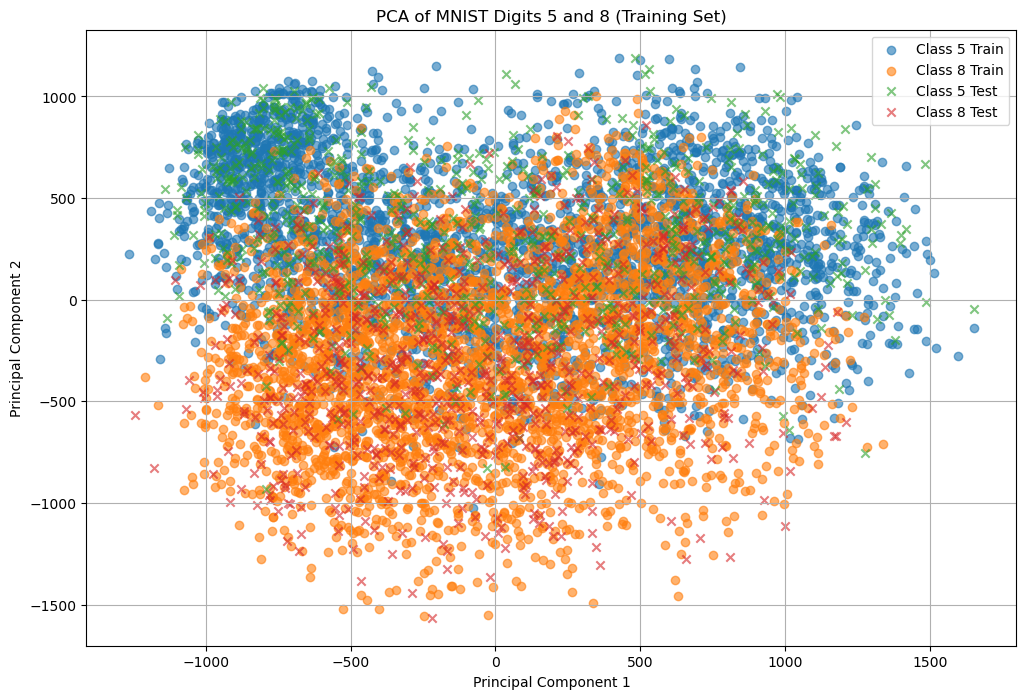

In [82]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==5, 0], Z_train[Y_train==5, 1], label='Class 5 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==8, 0], Z_train[Y_train==8, 1], label='Class 8 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==5, 0], Z_test[Y_test==5, 1], label='Class 5 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==8, 0], Z_test[Y_test==8, 1], label='Class 8 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 5 and 8 (Training Set)')
plt.legend()
plt.grid()
plt.show()

### 1vs7

In [83]:
filter_1or7 = (y==1) | (y==7)
X_filtered = X[filter_1or7]
Y_filtered = y[filter_1or7]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

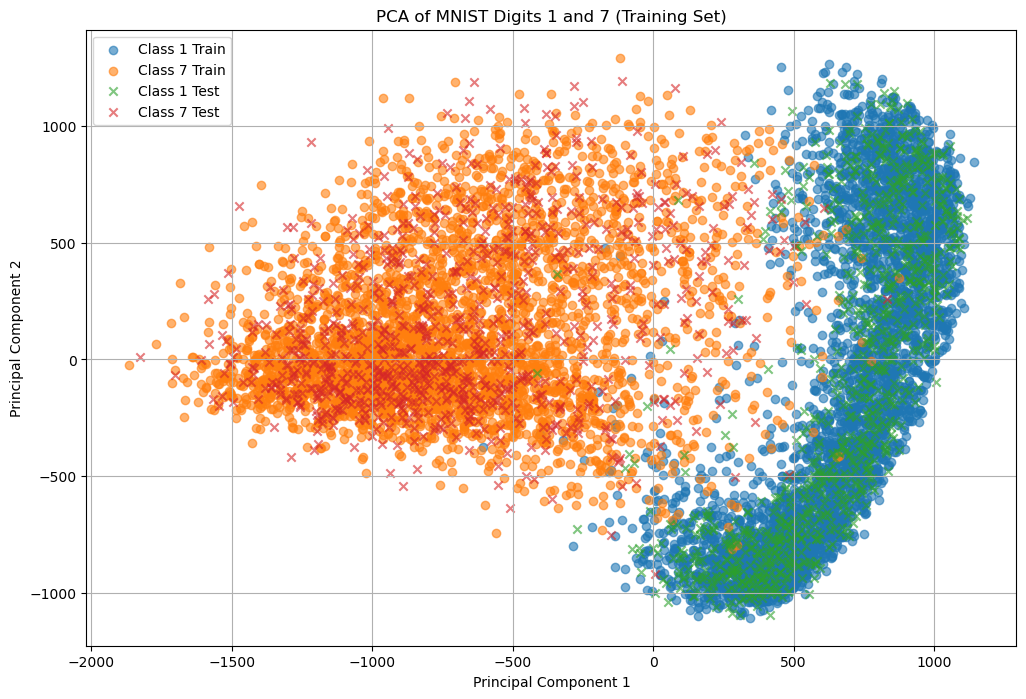

In [84]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==1, 0], Z_train[Y_train==1, 1], label='Class 1 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==7, 0], Z_train[Y_train==7, 1], label='Class 7 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==1, 0], Z_test[Y_test==1, 1], label='Class 1 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==7, 0], Z_test[Y_test==7, 1], label='Class 7 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 1 and 7 (Training Set)')
plt.legend()
plt.grid()
plt.show()

9.  Finally, try $k=3$ and use a 3D scatterplot.

In [85]:
filter_3or4 = (y==3) | (y==4)
X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 3
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

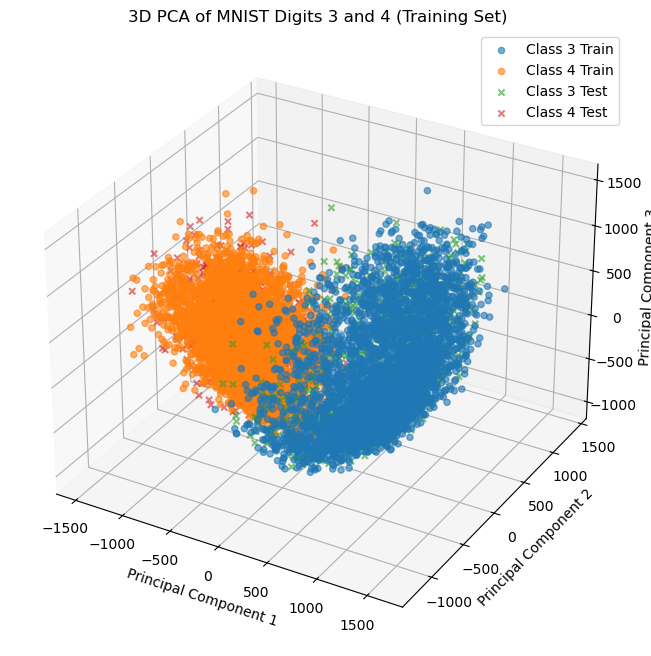

In [86]:
#3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], Z_train[Y_train==3, 2], label='Class 3 Train', alpha=0.6)
ax.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], Z_train[Y_train==4, 2], label='Class 4 Train', alpha=0.6)
ax.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], Z_test[Y_test==3, 2], label='Class 3 Test', alpha=0.6, marker='x')
ax.scatter(Z_test[Y_test==4, 0], Z_test[Y_test==4, 1], Z_test[Y_test==4, 2], label='Class 4 Test', alpha=0.6, marker='x')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.title('3D PCA of MNIST Digits 3 and 4 (Training Set)')
plt.legend()
plt.show()

## Exercise 6: Classification After PCA: Linear Classifier and Centroid Classifier

In this exercise, you will build two simple classifiers **after projecting the data with PCA**:

1. **A linear classifier on 2D PCA features**,  
2. **A PCA-centroid classifier** that assigns each test point to the closest class centroid in the reduced space.

You will perform all experiments on the same Kaggle dataset used previously: https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer, filtering only digits 3 and 4, as you did in the previosu exercise.

The aim of this exercise is to connect dimensionality reduction with classification and illustrates how PCA can be used not only for visualization, but also as a preprocessing tool for machine learning pipelines.

### Step 1: PCA Projection

Use exactly the same PCA workflow as in Exercise 6:

1. Load and split digits {3,4} into `train` and `test`.
2. Center the training data:
   
   $$
   X_{c,\text{train}} = X_{\text{train}} - c(X_{\text{train}}).
   $$
3. Compute the reduced SVD:
   
   $$
   X_{c,\text{train}} = U \Sigma V^T.
   $$

4. Take the first two principal directions:
   
   $$
   P = V_2 \in \mathbb{R}^{d \times 2}.
   $$

5. Project:
   
   $$
   Z_{\text{train}} = X_{c,\text{train}} P,
   \qquad
   Z_{\text{test}} = (X_{\text{test}} - c(X_{\text{train}}))\, P.
   $$

In [ ]:
filter_3or4 = (y==3) | (y==4)
X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

You will now use these 2D representations $Z_{\text{train}}$ and $Z_{\text{test}}$ for classification.

### Step 2: Fit a linear classifier

1. Use the logistic regression model:

    $$
    f_{\Theta}(z) = \sigma(\Theta^T z), \qquad z \in \mathbb{R}^2,
    $$

    with sigmoid and binary cross-entropy loss, and train the model using SGD.

In [88]:
def sigmoid(t):
    t = np.clip(t, -500, 500)
    return 1 / (1 + np.exp(-t))

def l(Theta, X, Y):
    Y_hat = sigmoid(X @ Theta)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)  # Avoid log(0)
    return - np.sum(Y * np.log(Y_hat) + (1-Y) * np.log(1 - Y_hat))

def grad_l(Theta, X, Y):
    Y_hat = sigmoid(X @ Theta)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)  # Avoid log(0)
    return X.T @ (Y_hat - Y)

def accuracy(Theta, X, Y):
    preds = sigmoid(X @ Theta) >= 0.5
    return (preds == Y).mean()

def ADAM(l, grad_l, X, Y, Theta0, lr=1e-3, batch_size=32, epochs=200,  beta1=0.9, beta2=0.999, eps=1e-8):
    epoch_loss = []
    epoch_acc = []

    Theta = Theta0
    
    m = np.zeros_like(Theta)
    v = np.zeros_like(Theta)
    t = 0
    
    for epoch in range(epochs):
        N = len(X)
        shuffle_idx = np.random.permutation(N)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])

            t += 1
            m = beta1 * m + (1 - beta1) * grad
            v = beta2 * v + (1 - beta2) * (grad * grad)
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            Theta -= lr * (m_hat / (np.sqrt(v_hat) + eps))


        epoch_loss.append(l(Theta, X, Y))
        epoch_acc.append(accuracy(Theta, X, Y))
            # Update the loss_val list

    return Theta, epoch, epoch_loss, epoch_acc

In [89]:
Z_train_bias = np.hstack((np.ones((Z_train.shape[0], 1)), Z_train))
Z_test_bias = np.hstack((np.ones((Z_test.shape[0], 1)), Z_test))

# Convert labels to binary: 0 for class 3, 1 for class 4
Y_train_binary = (Y_train == 4).astype(int)
Y_test_binary = (Y_test == 4).astype(int)
display_labels = ['3', '4']

In [90]:
Theta0 = np.zeros(Z_train_bias.shape[1])
Theta, epoch, epoch_train_loss, epoch_train_acc = ADAM(l, grad_l, Z_train_bias, Y_train_binary, Theta0=Theta0, lr=0.1, epochs=10)

2. Once trained:
   1. Plot the PCA-reduced training data in 2D,
   2. Plot the decision boundary defined by:
      
      $$
      \Theta^T z = 0 \quad \Rightarrow \quad \text{boundary line}.
      $$


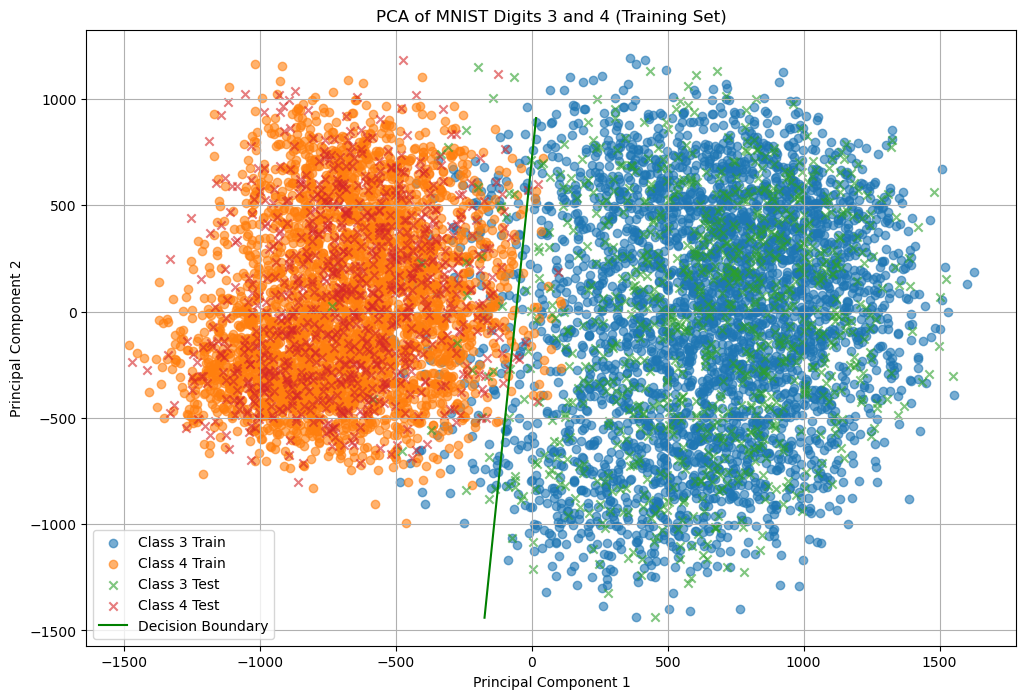

In [91]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], label='Class 3 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], label='Class 4 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], label='Class 3 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==4, 0], Z_test[Y_test==4, 1], label='Class 4 Test', alpha=0.6, marker='x')

pc1_q1 = np.percentile(Z_train[:, 0], 48)
pc1_q3 = np.percentile(Z_train[:, 0], 51)
pc1_range = np.array([pc1_q1, pc1_q3])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Decision Boundary', color='green')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 (Training Set)')
plt.legend()
plt.grid()
plt.show()

3.  Compute, on the test set:

    - Accuracy,
    - Precision and Recall,
    - Confusion matrix.

In [92]:
def classification_report(Y, Y_hat):
    # Get unique classes
    classes = np.unique(np.concatenate([Y, Y_hat]))
    
    # Overall accuracy
    accuracy = np.sum(Y == Y_hat) / len(Y)
    
    # Build confusion matrix
    n_classes = len(classes)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=int)
    for i, true_class in enumerate(classes):
        for j, pred_class in enumerate(classes):
            confusion_matrix[i, j] = np.sum((Y == true_class) & (Y_hat == pred_class))
    
    # Compute per-class metrics
    precision_per_class = []
    recall_per_class = []
    f1_per_class = []
    
    for i, cls in enumerate(classes):
        TP = confusion_matrix[i, i]
        FP = np.sum(confusion_matrix[:, i]) - TP
        FN = np.sum(confusion_matrix[i, :]) - TP
        TN = np.sum(confusion_matrix) - TP - FP - FN
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precision_per_class.append(precision)
        recall_per_class.append(recall)
        f1_per_class.append(f1)
    
    # Macro-averaged metrics
    macro_precision = np.mean(precision_per_class)
    macro_recall = np.mean(recall_per_class)
    macro_f1 = np.mean(f1_per_class)
    
    report = {
        'Accuracy': accuracy,
        'Macro-Precision': macro_precision,
        'Macro-Recall': macro_recall,
        'Macro-F1': macro_f1,
        'Confusion Matrix': confusion_matrix,
        'Classes': classes
    }
    return report

In [93]:
y_hat_test = (sigmoid(Z_test_bias @ Theta) >= 0.5).astype(int)

logistic_regression_report = classification_report(Y_test_binary, y_hat_test)

print("\nClassification Report - Test Set")
for key, value in logistic_regression_report.items():
    print(f"{key}: {value}")


Classification Report - Test Set
Accuracy: 0.9774480712166173
Macro-Precision: 0.9775298470243143
Macro-Recall: 0.977827401091713
Macro-F1: 0.9774457754595383
Confusion Matrix: [[832  32]
 [  6 815]]
Classes: [0 1]


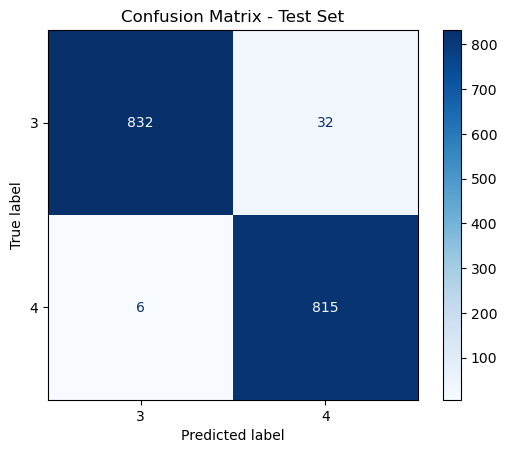

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=logistic_regression_report['Confusion Matrix'], display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - Test Set')
plt.show()


### Step 3: PCA-Centroid Classifier (Nearest-Centroid in PCA Space)

This classifier does **not** use a linear model. It relies purely on geometry in the reduced PCA space.

1. For each class $c\in\{3,4\}$, compute the centroid in PCA space:

    $$
    \mu_c = \frac{1}{|\mathcal{D}_c|}\sum_{z_i \in \mathcal{D}_c} z_i.
    $$

    Plot both centroids $\mu_3$ and $\mu_4$ in the PCA plane.

In [95]:
centroid_of_Z_3_train = np.mean(Z_train[Y_train==3], axis=0)
centroid_of_Z_4_train = np.mean(Z_train[Y_train==4], axis=0)

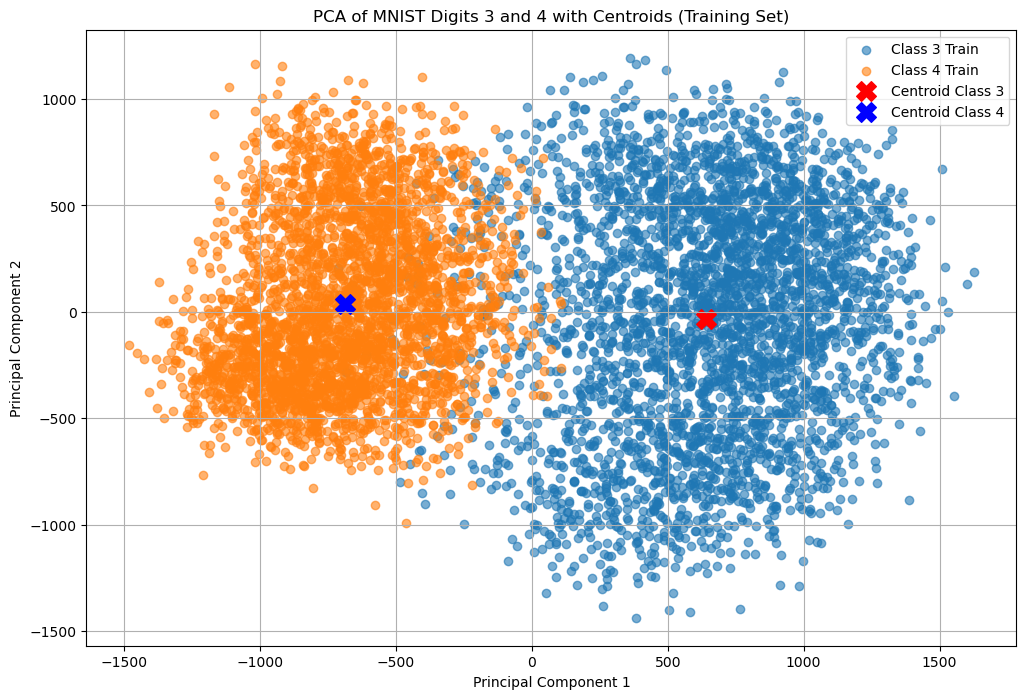

In [96]:
# Visualize centroids in PCA space
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], label='Class 3 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], label='Class 4 Train', alpha=0.6)
plt.scatter(centroid_of_Z_3_train[0], centroid_of_Z_3_train[1], color='red', marker='X', s=200, label='Centroid Class 3')
plt.scatter(centroid_of_Z_4_train[0], centroid_of_Z_4_train[1], color='blue', marker='X', s=200, label='Centroid Class 4')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 with Centroids (Training Set)')
plt.legend()
plt.grid()
plt.show()


2. Given a test sample $x\in\mathbb{R}^d$:

   1. Project it:
      
      $$
      z = (x - c(X_{\text{train}}))\, P.
      $$

   2. Compute distances:
      
      $$
      d_3 = \|z - \mu_3\|_2,\qquad
      d_4 = \|z - \mu_4\|_2.
      $$

   3. Assign:
      
      $$
      \hat y = \arg\min_{c\in\{3,4\}} d_c.
      $$


    This is the **nearest-centroid classifier in PCA space**.

In [97]:
def nearest_centroid_classifier_in_PCA_space(X):
    Z = (X - centroid_of_X_train) @ P_train.T 
    d_3 = np.linalg.norm(Z - centroid_of_Z_3_train, axis=1)
    d_4 = np.linalg.norm(Z - centroid_of_Z_4_train, axis=1)
    preds = (d_3 >= d_4).astype(int)  # 0 -> class 3, 1 -> class 4
    return preds

3.  Compute, on the test set:

    - Accuracy,
    - Precision and Recall,
    - Confusion matrix.

    Plot the test points with colors given by classification results.

In [98]:
y_hat = nearest_centroid_classifier_in_PCA_space(X_test)
centroid_classifier_report = classification_report(Y_test_binary, y_hat)

print("\nNearest Centroid Classifier")
for key, value in centroid_classifier_report.items():
    print(f"{key}: {value}")


Nearest Centroid Classifier
Accuracy: 0.9762611275964391
Macro-Precision: 0.9764941608801515
Macro-Recall: 0.9767306130734876
Macro-F1: 0.9762601158675414
Confusion Matrix: [[828  36]
 [  4 817]]
Classes: [0 1]


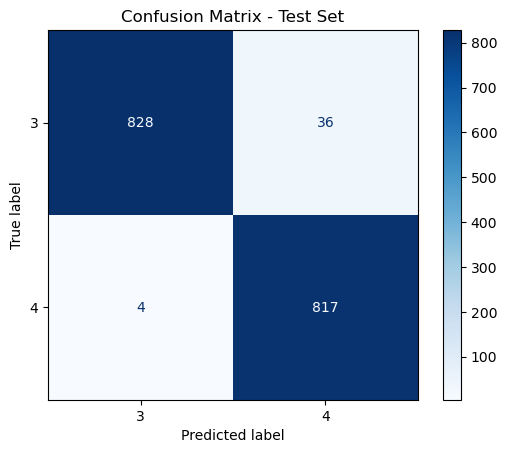

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=centroid_classifier_report['Confusion Matrix'], display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - Test Set')
plt.show()

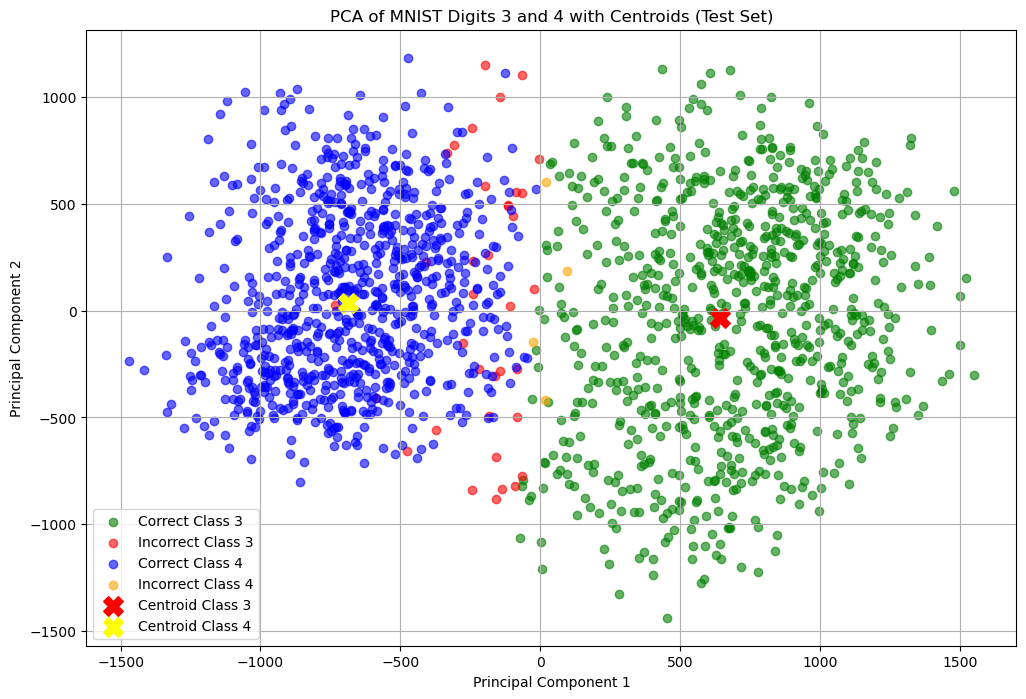

In [100]:
correct_3_classification = Z_test[(Y_test==3) & (y_hat==0)]
incorrect_3_classification = Z_test[(Y_test==3) & (y_hat==1)]
correct_4_classification = Z_test[(Y_test==4) & (y_hat==1)]
incorrect_4_classification = Z_test[(Y_test==4) & (y_hat==0)]



plt.figure(figsize=(12, 8))
plt.scatter(correct_3_classification[:, 0], correct_3_classification[:, 1], color='green', label='Correct Class 3', alpha=0.6)
plt.scatter(incorrect_3_classification[:, 0], incorrect_3_classification[:, 1], color='red', label='Incorrect Class 3', alpha=0.6)
plt.scatter(correct_4_classification[:, 0], correct_4_classification[:, 1], color='blue', label='Correct Class 4', alpha=0.6)
plt.scatter(incorrect_4_classification[:, 0], incorrect_4_classification[:, 1], color='orange', label='Incorrect Class 4', alpha=0.6)
plt.scatter(centroid_of_Z_3_train[0], centroid_of_Z_3_train[1], color='red', marker='X', s=200, label='Centroid Class 3')
plt.scatter(centroid_of_Z_4_train[0], centroid_of_Z_4_train[1], color='yellow', marker='X', s=200, label='Centroid Class 4')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 with Centroids (Test Set)')
plt.legend()
plt.grid()
plt.show()

### Step 4: Compare accuracy and error patterns

1. Compare linear classifier on PCA features vs centroid classifier in PCA space.

In [101]:

print(f"Logistic Regression Accuracy:         {logistic_regression_report['Accuracy']}")
print(f"Nearest Centroid Classifier Accuracy: {centroid_classifier_report['Accuracy']}")
print('\n')

print(f"Logistic Regression Macro-F1:         {logistic_regression_report['Macro-F1']}")
print(f"Nearest Centroid Classifier Macro-F1: {centroid_classifier_report['Macro-F1']}")
print('\n')

print(f"Logistic Regression Macro-Precision:         {logistic_regression_report['Macro-Precision']}")
print(f"Nearest Centroid Classifier Macro-Precision: {centroid_classifier_report['Macro-Precision']}")
print('\n')

print(f"Logistic Regression Macro-Recall:         {logistic_regression_report['Macro-Recall']}")
print(f"Nearest Centroid Classifier Macro-Recall: {centroid_classifier_report['Macro-Recall']}")


Logistic Regression Accuracy:         0.9774480712166173
Nearest Centroid Classifier Accuracy: 0.9762611275964391


Logistic Regression Macro-F1:         0.9774457754595383
Nearest Centroid Classifier Macro-F1: 0.9762601158675414


Logistic Regression Macro-Precision:         0.9775298470243143
Nearest Centroid Classifier Macro-Precision: 0.9764941608801515


Logistic Regression Macro-Recall:         0.977827401091713
Nearest Centroid Classifier Macro-Recall: 0.9767306130734876


2. On the PCA scatterplot, plot:

   - the linear boundary,
   - the two centroids,
   - misclassified test samples highlighted in red.

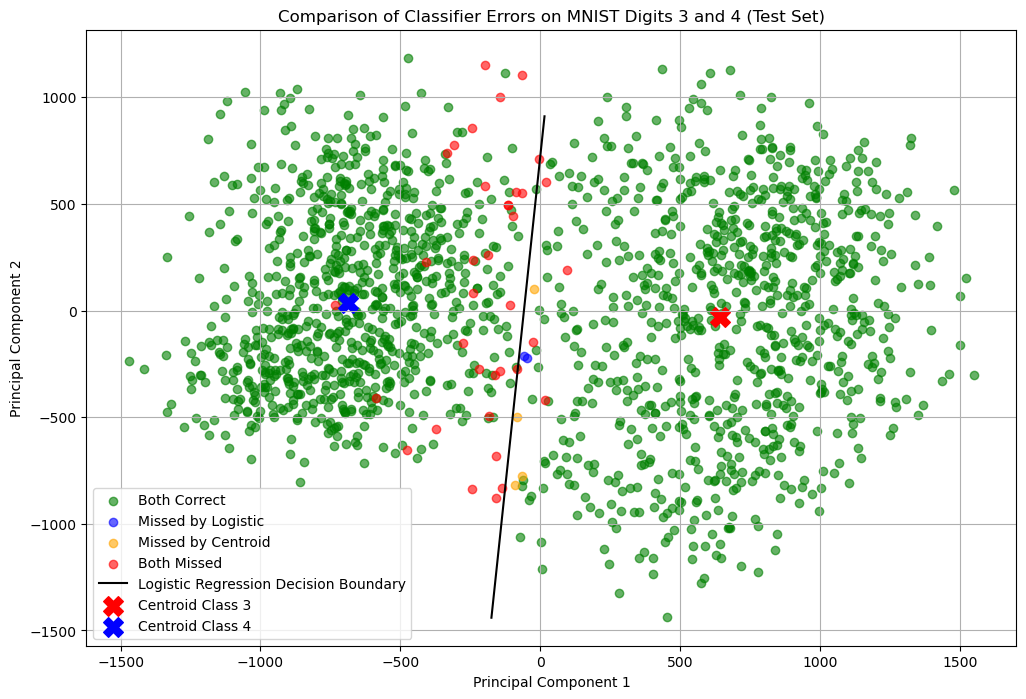

In [102]:
missclassified_by_logistic = (Y_test_binary != y_hat_test)
missclassified_by_centroid = (Y_test_binary != y_hat)
both_missclassified = missclassified_by_logistic & missclassified_by_centroid
both_classified_correctly = ~missclassified_by_logistic & ~missclassified_by_centroid

plt.figure(figsize=(12, 8))
plt.scatter(Z_test[both_classified_correctly, 0], Z_test[both_classified_correctly, 1], color='green', label='Both Correct', alpha=0.6)
plt.scatter(Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 0], Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 1], color='blue', label='Missed by Logistic', alpha=0.6)
plt.scatter(Z_test[~missclassified_by_logistic & missclassified_by_centroid, 0], Z_test[~missclassified_by_logistic & missclassified_by_centroid, 1], color='orange', label='Missed by Centroid', alpha=0.6)
plt.scatter(Z_test[both_missclassified, 0], Z_test[both_missclassified, 1], color='red', label='Both Missed', alpha=0.6)

# Plot decision boundary
pc1_q1 = np.percentile(Z_train[:, 0], 48)
pc1_q3 = np.percentile(Z_train[:, 0], 51)
pc1_range = np.array([pc1_q1, pc1_q3])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Logistic Regression Decision Boundary', color='black')

# Plot centroids
plt.scatter(centroid_of_Z_3_train[0], centroid_of_Z_3_train[1], color='red', marker='X', s=200, label='Centroid Class 3')
plt.scatter(centroid_of_Z_4_train[0], centroid_of_Z_4_train[1], color='blue', marker='X', s=200, label='Centroid Class 4') 

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Comparison of Classifier Errors on MNIST Digits 3 and 4 (Test Set)')
plt.legend()
plt.grid()
plt.show()

3. Repeat by changing the digits in $\{ (1,7), (5,8), (2,3) \}$ and observe how class similarity influences:
   - the cluster shape,
   - centroid separation,
   - decision boundaries.

## 1 vs 7

In [112]:
filter_1or7 = (y==1) | (y==7)
X_filtered = X[filter_1or7]
Y_filtered = y[filter_1or7]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]



centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

Y_train_binary = (Y_train == 7).astype(int)
Y_test_binary = (Y_test == 7).astype(int)
display_labels = ['1', '7']

# Logistic regression
Z_train_bias = np.hstack((np.ones((Z_train.shape[0], 1)), Z_train))
Z_test_bias = np.hstack((np.ones((Z_test.shape[0], 1)), Z_test))
Theta0 = np.zeros(Z_train_bias.shape[1])
Theta, epoch, epoch_train_loss, epoch_train_acc = ADAM(l, grad_l, Z_train_bias, Y_train_binary, Theta0=Theta0, lr=0.1, epochs=10)
y_hat_test = (sigmoid(Z_test_bias @ Theta) >= 0.5).astype(int)
logistic_regression_report = classification_report(Y_test_binary, y_hat_test)

# Nearest Centroid Classifier
centroid_of_Z_1_train = np.mean(Z_train[Y_train==1], axis=0)
centroid_of_Z_7_train = np.mean(Z_train[Y_train==7], axis=0)
Z = (X_test - centroid_of_X_train) @ P_train.T 
d_1 = np.linalg.norm(Z - centroid_of_Z_1_train, axis=1)
d_7 = np.linalg.norm(Z - centroid_of_Z_7_train, axis=1)
y_hat = (d_1 >= d_7).astype(int)
centroid_classifier_report = classification_report(Y_test_binary, y_hat)


print(f"Logistic Regression Accuracy:         {logistic_regression_report['Accuracy']}")
print(f"Nearest Centroid Classifier Accuracy: {centroid_classifier_report['Accuracy']}")
print('\n')

print(f"Logistic Regression Macro-F1:         {logistic_regression_report['Macro-F1']}")
print(f"Nearest Centroid Classifier Macro-F1: {centroid_classifier_report['Macro-F1']}")
print('\n')

print(f"Logistic Regression Macro-Precision:         {logistic_regression_report['Macro-Precision']}")
print(f"Nearest Centroid Classifier Macro-Precision: {centroid_classifier_report['Macro-Precision']}")
print('\n')

print(f"Logistic Regression Macro-Recall:         {logistic_regression_report['Macro-Recall']}")
print(f"Nearest Centroid Classifier Macro-Recall: {centroid_classifier_report['Macro-Recall']}")


Logistic Regression Accuracy:         0.9719317556411667
Nearest Centroid Classifier Accuracy: 0.9587231700605393


Logistic Regression Macro-F1:         0.9718359044122139
Nearest Centroid Classifier Macro-F1: 0.9584474864960049


Logistic Regression Macro-Precision:         0.9727822556090622
Nearest Centroid Classifier Macro-Precision: 0.9625621762167369


Logistic Regression Macro-Recall:         0.9712612840098478
Nearest Centroid Classifier Macro-Recall: 0.956993900928943


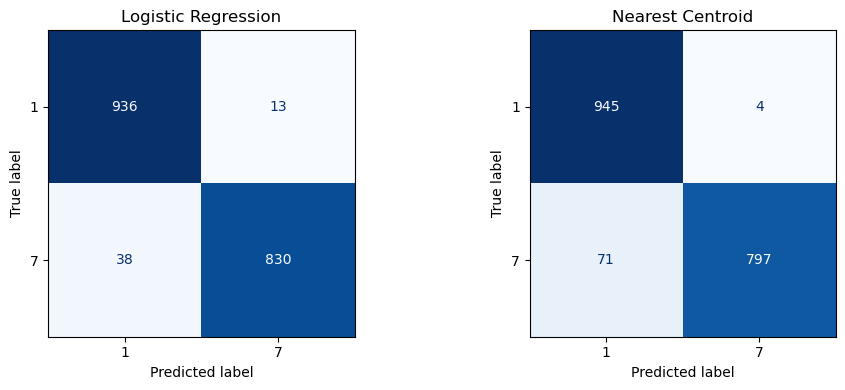

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix=logistic_regression_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix=centroid_classifier_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=False)
axes[1].set_title('Nearest Centroid')

plt.tight_layout()
plt.show()

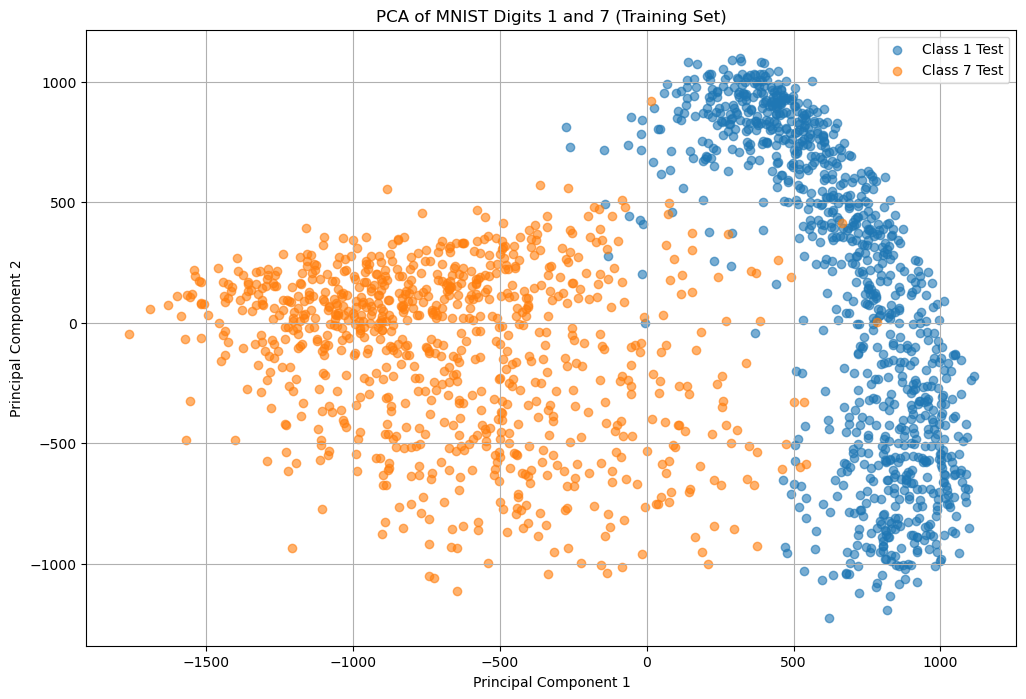

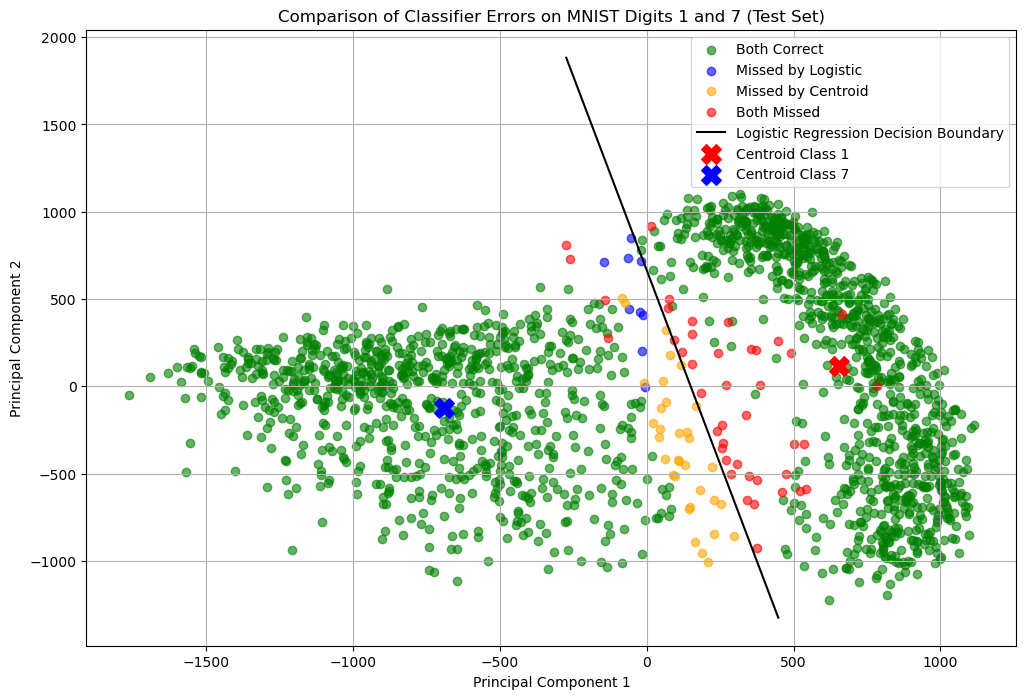

In [117]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_test[Y_test==1, 0], Z_test[Y_test==1, 1], label='Class 1 Test', alpha=0.6)
plt.scatter(Z_test[Y_test==7, 0], Z_test[Y_test==7, 1], label='Class 7 Test', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 1 and 7 (Training Set)')
plt.legend()
plt.grid()
plt.show()

missclassified_by_logistic = (Y_test_binary != y_hat_test)
missclassified_by_centroid = (Y_test_binary != y_hat)
both_missclassified = missclassified_by_logistic & missclassified_by_centroid
both_classified_correctly = ~missclassified_by_logistic & ~missclassified_by_centroid

plt.figure(figsize=(12, 8))
plt.scatter(Z_test[both_classified_correctly, 0], Z_test[both_classified_correctly, 1], color='green', label='Both Correct', alpha=0.6)
plt.scatter(Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 0], Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 1], color='blue', label='Missed by Logistic', alpha=0.6)
plt.scatter(Z_test[~missclassified_by_logistic & missclassified_by_centroid, 0], Z_test[~missclassified_by_logistic & missclassified_by_centroid, 1], color='orange', label='Missed by Centroid', alpha=0.6)
plt.scatter(Z_test[both_missclassified, 0], Z_test[both_missclassified, 1], color='red', label='Both Missed', alpha=0.6)

# Plot decision boundary
pc1_q1 = np.percentile(Z_train[:, 0], 40)
pc1_q3 = np.percentile(Z_train[:, 0], 60)
pc1_range = np.array([pc1_q1, pc1_q3])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Logistic Regression Decision Boundary', color='black')

# Plot centroids
plt.scatter(centroid_of_Z_1_train[0], centroid_of_Z_1_train[1], color='red', marker='X', s=200, label='Centroid Class 1')
plt.scatter(centroid_of_Z_7_train[0], centroid_of_Z_7_train[1], color='blue', marker='X', s=200, label='Centroid Class 7') 

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Comparison of Classifier Errors on MNIST Digits 1 and 7 (Test Set)')
plt.legend()
plt.grid()
plt.show()



## 5 vs 8

In [106]:
filter_5or8 = (y==5) | (y==8)
X_filtered = X[filter_5or8]
Y_filtered = y[filter_5or8]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]



centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

Y_train_binary = (Y_train == 8).astype(int)
Y_test_binary = (Y_test == 8).astype(int)
display_labels = ['5', '8']

# Logistic regression
Z_train_bias = np.hstack((np.ones((Z_train.shape[0], 1)), Z_train))
Z_test_bias = np.hstack((np.ones((Z_test.shape[0], 1)), Z_test))
Theta0 = np.zeros(Z_train_bias.shape[1])
Theta, epoch, epoch_train_loss, epoch_train_acc = ADAM(l, grad_l, Z_train_bias, Y_train_binary, Theta0=Theta0, lr=0.1, epochs=10)
y_hat_test = (sigmoid(Z_test_bias @ Theta) >= 0.5).astype(int)
logistic_regression_report = classification_report(Y_test_binary, y_hat_test)

# Nearest Centroid Classifier
centroid_of_Z_5_train = np.mean(Z_train[Y_train==5], axis=0)
centroid_of_Z_8_train = np.mean(Z_train[Y_train==8], axis=0)
Z = (X_test - centroid_of_X_train) @ P_train.T 
d_5 = np.linalg.norm(Z - centroid_of_Z_5_train, axis=1)
d_8 = np.linalg.norm(Z - centroid_of_Z_8_train, axis=1)
y_hat = (d_5 >= d_8).astype(int)
centroid_classifier_report = classification_report(Y_test_binary, y_hat)


print(f"Logistic Regression Accuracy:         {logistic_regression_report['Accuracy']}")
print(f"Nearest Centroid Classifier Accuracy: {centroid_classifier_report['Accuracy']}")
print('\n')

print(f"Logistic Regression Macro-F1:         {logistic_regression_report['Macro-F1']}")
print(f"Nearest Centroid Classifier Macro-F1: {centroid_classifier_report['Macro-F1']}")
print('\n')

print(f"Logistic Regression Macro-Precision:         {logistic_regression_report['Macro-Precision']}")
print(f"Nearest Centroid Classifier Macro-Precision: {centroid_classifier_report['Macro-Precision']}")
print('\n')

print(f"Logistic Regression Macro-Recall:         {logistic_regression_report['Macro-Recall']}")
print(f"Nearest Centroid Classifier Macro-Recall: {centroid_classifier_report['Macro-Recall']}")


Logistic Regression Accuracy:         0.7589058524173028
Nearest Centroid Classifier Accuracy: 0.7659033078880407


Logistic Regression Macro-F1:         0.7584130360648187
Nearest Centroid Classifier Macro-F1: 0.7658062635618745


Logistic Regression Macro-Precision:         0.7583984650591741
Nearest Centroid Classifier Macro-Precision: 0.766026740911004


Logistic Regression Macro-Recall:         0.7584282238442822
Nearest Centroid Classifier Macro-Recall: 0.7665790754257907


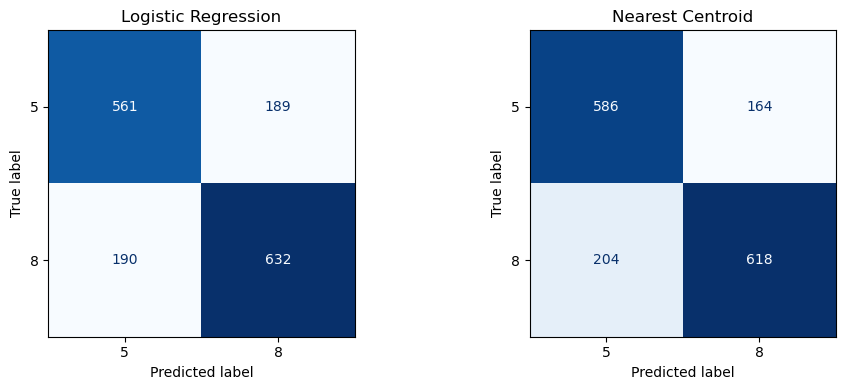

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix=logistic_regression_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix=centroid_classifier_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=False)
axes[1].set_title('Nearest Centroid')

plt.tight_layout()
plt.show()

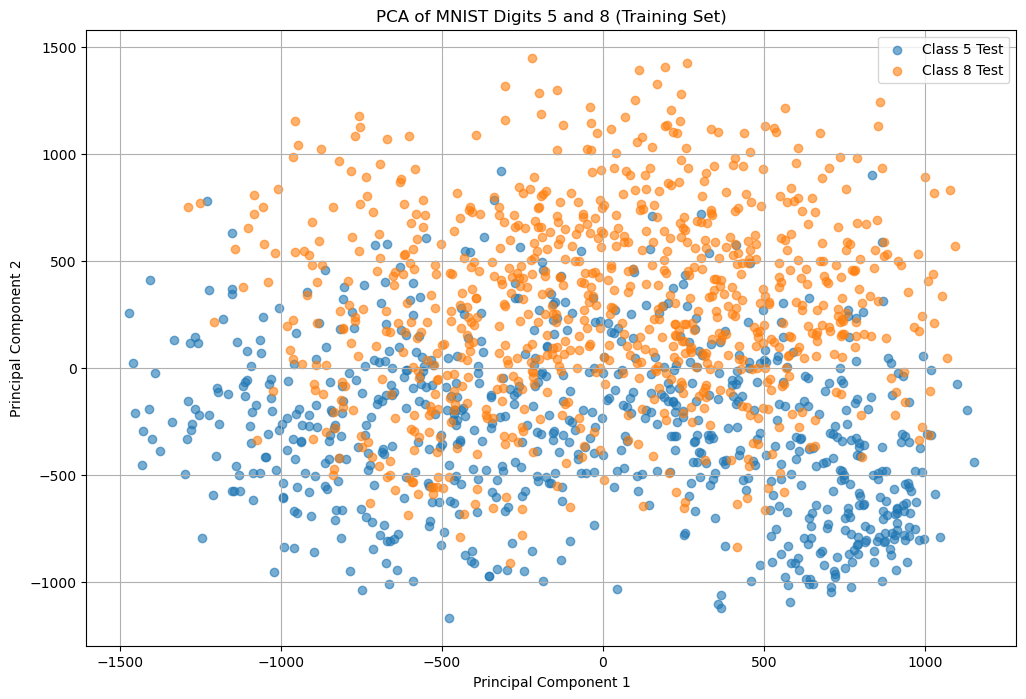

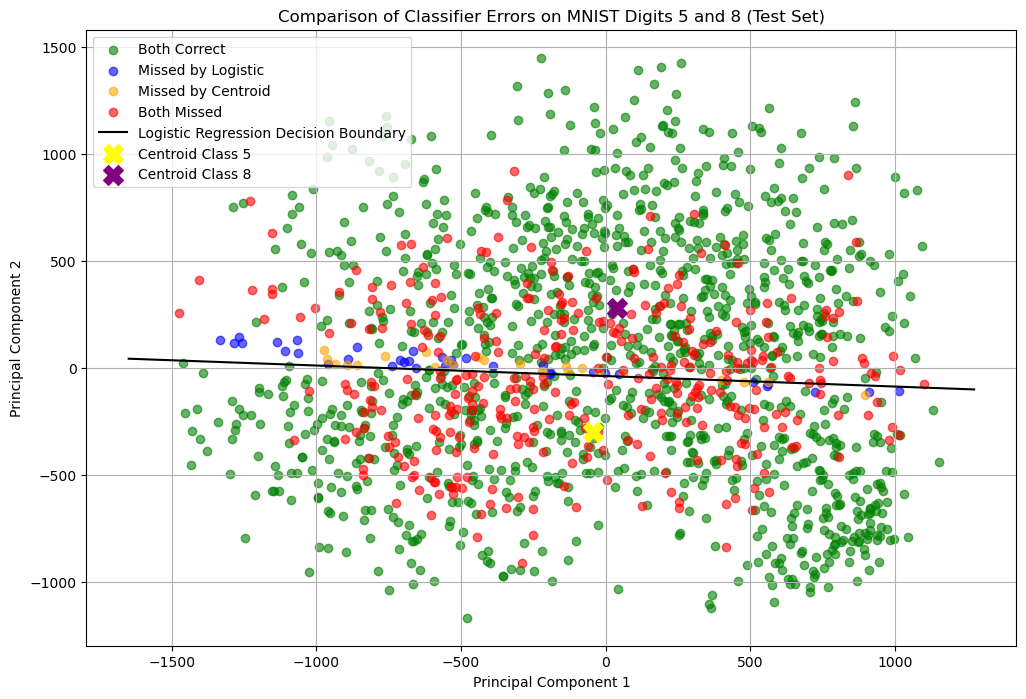

In [108]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_test[Y_test==5, 0], Z_test[Y_test==5, 1], label='Class 5 Test', alpha=0.6)
plt.scatter(Z_test[Y_test==8, 0], Z_test[Y_test==8, 1], label='Class 8 Test', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 5 and 8 (Training Set)')
plt.legend()
plt.grid()
plt.show()

missclassified_by_logistic = (Y_test_binary != y_hat_test)
missclassified_by_centroid = (Y_test_binary != y_hat)
both_missclassified = missclassified_by_logistic & missclassified_by_centroid
both_classified_correctly = ~missclassified_by_logistic & ~missclassified_by_centroid

plt.figure(figsize=(12, 8))
plt.scatter(Z_test[both_classified_correctly, 0], Z_test[both_classified_correctly, 1], color='green', label='Both Correct', alpha=0.6)
plt.scatter(Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 0], Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 1], color='blue', label='Missed by Logistic', alpha=0.6)
plt.scatter(Z_test[~missclassified_by_logistic & missclassified_by_centroid, 0], Z_test[~missclassified_by_logistic & missclassified_by_centroid, 1], color='orange', label='Missed by Centroid', alpha=0.6)
plt.scatter(Z_test[both_missclassified, 0], Z_test[both_missclassified, 1], color='red', label='Both Missed', alpha=0.6)

# Plot decision boundary
#pc1_q1 = np.percentile(Z_train[:, 0], 20)
#pc1_q3 = np.percentile(Z_train[:, 0], 80)
pc1_range = np.array([Z_train[:, 0].min(), Z_train[:, 0].max()])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Logistic Regression Decision Boundary', color='black')

# Plot centroids
plt.scatter(centroid_of_Z_5_train[0], centroid_of_Z_5_train[1], color='yellow', marker='X', s=200, label='Centroid Class 5')
plt.scatter(centroid_of_Z_8_train[0], centroid_of_Z_8_train[1], color='purple', marker='X', s=200, label='Centroid Class 8') 

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Comparison of Classifier Errors on MNIST Digits 5 and 8 (Test Set)')
plt.legend()
plt.grid()
plt.show()

## 2 vs 3

In [126]:
filter_2or3 = (y==2) | (y==3)
X_filtered = X[filter_2or3]
Y_filtered = y[filter_2or3]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]



centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

Y_train_binary = (Y_train == 3).astype(int)
Y_test_binary = (Y_test == 3).astype(int)
display_labels = ['2', '3']

# Logistic regression
Z_train_bias = np.hstack((np.ones((Z_train.shape[0], 1)), Z_train))
Z_test_bias = np.hstack((np.ones((Z_test.shape[0], 1)), Z_test))
Theta0 = np.zeros(Z_train_bias.shape[1])
Theta, epoch, epoch_train_loss, epoch_train_acc = ADAM(l, grad_l, Z_train_bias, Y_train_binary, Theta0=Theta0, lr=0.1, epochs=10)
y_hat_test = (sigmoid(Z_test_bias @ Theta) >= 0.5).astype(int)
logistic_regression_report = classification_report(Y_test_binary, y_hat_test)

# Nearest Centroid Classifier
centroid_of_Z_2_train = np.mean(Z_train[Y_train==2], axis=0)
centroid_of_Z_3_train = np.mean(Z_train[Y_train==3], axis=0)
Z = (X_test - centroid_of_X_train) @ P_train.T 
d_2 = np.linalg.norm(Z - centroid_of_Z_2_train, axis=1)
d_3 = np.linalg.norm(Z - centroid_of_Z_3_train, axis=1)
y_hat = (d_2 >= d_3).astype(int)
centroid_classifier_report = classification_report(Y_test_binary, y_hat)


print(f"Logistic Regression Accuracy:         {logistic_regression_report['Accuracy']}")
print(f"Nearest Centroid Classifier Accuracy: {centroid_classifier_report['Accuracy']}")
print('\n')

print(f"Logistic Regression Macro-F1:         {logistic_regression_report['Macro-F1']}")
print(f"Nearest Centroid Classifier Macro-F1: {centroid_classifier_report['Macro-F1']}")
print('\n')

print(f"Logistic Regression Macro-Precision:         {logistic_regression_report['Macro-Precision']}")
print(f"Nearest Centroid Classifier Macro-Precision: {centroid_classifier_report['Macro-Precision']}")
print('\n')

print(f"Logistic Regression Macro-Recall:         {logistic_regression_report['Macro-Recall']}")
print(f"Nearest Centroid Classifier Macro-Recall: {centroid_classifier_report['Macro-Recall']}")


Logistic Regression Accuracy:         0.902696365767878
Nearest Centroid Classifier Accuracy: 0.9015240328253223


Logistic Regression Macro-F1:         0.9026930223864187
Nearest Centroid Classifier Macro-F1: 0.9015011547344111


Logistic Regression Macro-Precision:         0.9027517185354408
Nearest Centroid Classifier Macro-Precision: 0.9018974238341084


Logistic Regression Macro-Recall:         0.9026963657678782
Nearest Centroid Classifier Macro-Recall: 0.9015240328253225


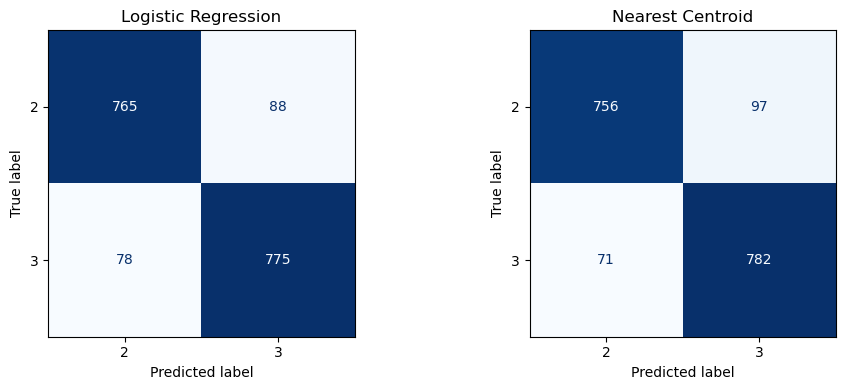

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix=logistic_regression_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix=centroid_classifier_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=False)
axes[1].set_title('Nearest Centroid')

plt.tight_layout()
plt.show()

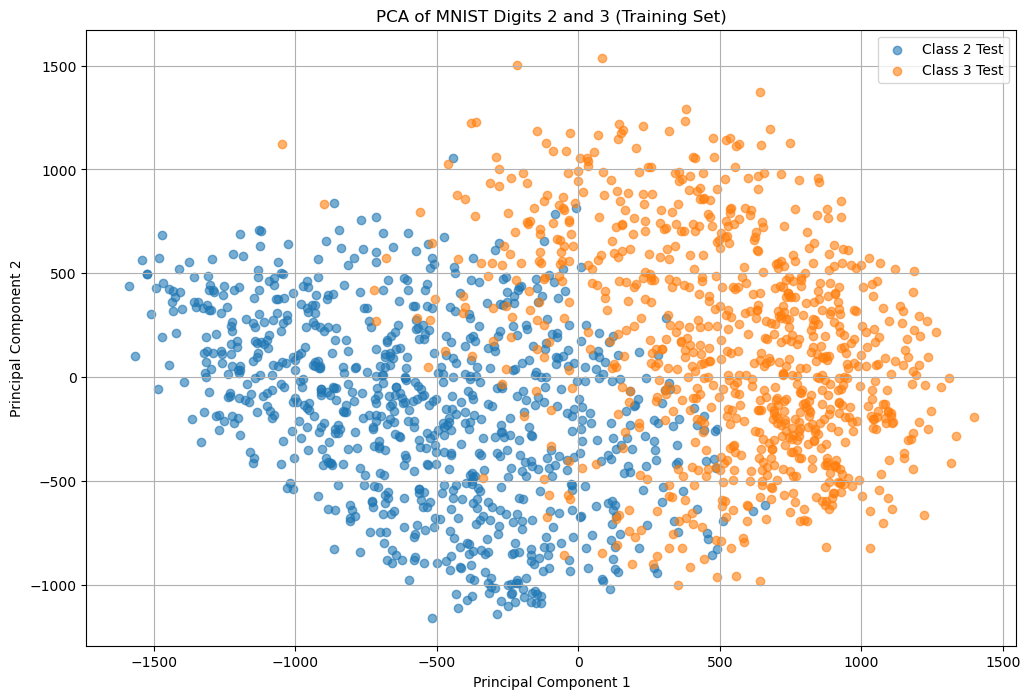

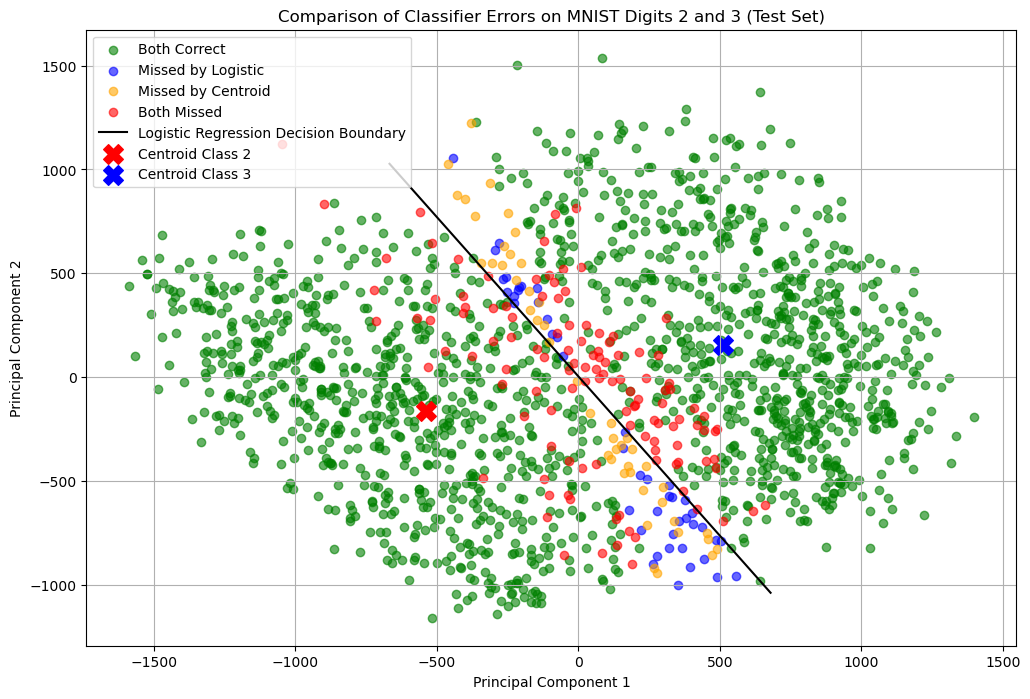

In [130]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_test[Y_test==2, 0], Z_test[Y_test==2, 1], label='Class 2 Test', alpha=0.6)
plt.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], label='Class 3 Test', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 2 and 3 (Training Set)')
plt.legend()
plt.grid()
plt.show()


missclassified_by_logistic = (Y_test_binary != y_hat_test)
missclassified_by_centroid = (Y_test_binary != y_hat)
both_missclassified = missclassified_by_logistic & missclassified_by_centroid
both_classified_correctly = ~missclassified_by_logistic & ~missclassified_by_centroid

plt.figure(figsize=(12, 8))
plt.scatter(Z_test[both_classified_correctly, 0], Z_test[both_classified_correctly, 1], color='green', label='Both Correct', alpha=0.6)
plt.scatter(Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 0], Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 1], color='blue', label='Missed by Logistic', alpha=0.6)
plt.scatter(Z_test[~missclassified_by_logistic & missclassified_by_centroid, 0], Z_test[~missclassified_by_logistic & missclassified_by_centroid, 1], color='orange', label='Missed by Centroid', alpha=0.6)
plt.scatter(Z_test[both_missclassified, 0], Z_test[both_missclassified, 1], color='red', label='Both Missed', alpha=0.6)

# Plot decision boundary
pc1_q1 = np.percentile(Z_train[:, 0], 20)
pc1_q3 = np.percentile(Z_train[:, 0], 80)
pc1_range = np.array([pc1_q1, pc1_q3])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Logistic Regression Decision Boundary', color='black')

# Plot centroids
plt.scatter(centroid_of_Z_2_train[0], centroid_of_Z_2_train[1], color='red', marker='X', s=200, label='Centroid Class 2')
plt.scatter(centroid_of_Z_3_train[0], centroid_of_Z_3_train[1], color='blue', marker='X', s=200, label='Centroid Class 3') 

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Comparison of Classifier Errors on MNIST Digits 2 and 3 (Test Set)')
plt.legend()
plt.grid()
plt.show()